In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [49]:
import os
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from lightgbm import LGBMRegressor
import optuna
import shap
import matplotlib.pyplot as plt
import joblib

In [3]:
df = pd.read_parquet('../data/processed/processed_data.parquet')

In [4]:
# df = pd.read_parquet('https://github.com/iamnitishsah/FoodOps.AI/raw/refs/heads/main/DeliveryOps/data/processed/processed_data.parquet')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195788 entries, 0 to 195787
Data columns (total 27 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     195788 non-null  float64
 1   store_id                                      195788 non-null  int64  
 2   order_protocol                                195788 non-null  float64
 3   total_items                                   195788 non-null  int64  
 4   subtotal                                      195788 non-null  int64  
 5   num_distinct_items                            195788 non-null  int64  
 6   min_item_price                                195788 non-null  int64  
 7   max_item_price                                195788 non-null  int64  
 8   total_onshift_dashers                         195788 non-null  float64
 9   total_busy_dashers                            19

In [6]:
df.sample(10)

,market_id,store_id,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,...,outstanding_order_ratio,order_date,is_train,store_category_target_enc,hour_sin,hour_cos,dow_sin,dow_cos,target_raw,target_log1p
31628,2.0,1653,3.0,4,3800,4,800,1300,32.0,43.0,...,1.062500,2015-01-25,True,2987.599722,-0.965926,-2.588190e-01,-0.781831,0.623490,3486.0,8.156797
72138,2.0,1546,1.0,1,810,1,810,810,41.0,50.0,...,1.804878,2015-01-31,True,2631.689728,-0.866025,5.000000e-01,-0.974928,-0.222521,1815.0,7.504392
121969,3.0,5629,1.0,2,1258,2,589,669,16.0,15.0,...,0.937500,2015-02-07,True,2631.689728,-0.866025,5.000000e-01,-0.974928,-0.222521,2313.0,7.746733
148034,6.0,1036,2.0,1,1275,1,1075,1075,58.0,56.0,...,1.448276,2015-02-11,False,3045.475141,-1.000000,-1.836970e-16,0.974928,-0.222521,2240.0,7.714677
188126,3.0,4163,3.0,2,2795,2,1100,1695,42.0,41.0,...,1.214286,2015-02-16,False,2823.111878,-0.965926,2.588190e-01,0.000000,1.000000,2878.0,7.965198
53900,1.0,102,5.0,1,430,1,1168,1104,43.0,46.0,...,1.255814,2015-01-29,True,2728.575827,-0.965926,-2.588190e-01,0.433884,-0.900969,2471.0,7.812783
120801,5.0,2817,1.0,4,1250,4,0,750,15.0,16.0,...,2.266667,2015-02-07,True,2803.157240,-0.965926,2.588190e-01,-0.974928,-0.222521,5208.0,8.558143
149746,6.0,3242,4.0,7,1101,2,246,301,37.0,36.0,...,1.378378,2015-02-11,False,2596.082899,-0.866025,5.000000e-01,0.974928,-0.222521,1278.0,7.153834
145358,1.0,1773,2.0,4,4475,4,700,1325,9.0,2.0,...,0.111111,2015-02-11,False,2952.562922,-0.500000,-8.660254e-01,0.974928,-0.222521,2233.0,7.711549
190067,6.0,5502,3.0,10,10775,8,395,1495,27.0,26.0,...,1.259259,2015-02-17,False,2810.958715,0.258819,-9.659258e-01,0.781831,0.623490,4316.0,8.370316


## Train-test split

In [7]:
train_df = df[df["is_train"]].copy()
test_df = df[~df["is_train"]].copy()

In [8]:
feature_drop_cols = [
    "is_train",
    "store_id",
    "order_date",
    "target_raw",
    "target_log1p",
]

In [9]:
X_train = train_df.drop(columns=feature_drop_cols)
y_train = train_df["target_log1p"]

X_test = test_df.drop(columns=feature_drop_cols)
y_test = test_df["target_log1p"]

In [10]:
y_train_raw = train_df["target_raw"]
y_test_raw = test_df["target_raw"]

In [11]:
X_train.info()
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 143468 entries, 0 to 143467
Data columns (total 22 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     143468 non-null  float64
 1   order_protocol                                143468 non-null  float64
 2   total_items                                   143468 non-null  int64  
 3   subtotal                                      143468 non-null  int64  
 4   num_distinct_items                            143468 non-null  int64  
 5   min_item_price                                143468 non-null  int64  
 6   max_item_price                                143468 non-null  int64  
 7   total_onshift_dashers                         143468 non-null  float64
 8   total_busy_dashers                            143468 non-null  float64
 9   total_outstanding_orders                      143468 

# Naive Baseline Model

In [12]:
naive_prediction = y_train_raw.median()
y_pred_naive = np.full_like(y_test_raw, fill_value=naive_prediction)

In [13]:
naive_mae = mean_absolute_error(y_test_raw, y_pred_naive)
print(f"Naive Baseline (Predicting {naive_prediction:.0f}s for everything):")
print(f"Test MAE: {naive_mae:.2f} seconds ({naive_mae/60:.2f} minutes)")

Naive Baseline (Predicting 2630s for everything):
Test MAE: 784.93 seconds (13.08 minutes)


# Ridge Regression Model

In [14]:
# Separate features by type for proper preprocessing
categorical_cols = ["market_id", "order_protocol"]

# Everything else (numerics, booleans, cyclical encodings) can be scaled
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

In [15]:
# Build the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [16]:
# Assemble the Ridge Pipeline
ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

In [17]:
# Train the model (fitting on the log-transformed target)
print("Training Ridge Regression...")
ridge_pipeline.fit(X_train, y_train)

Training Ridge Regression...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['market_id','order_protocol','total_items',...,'hour_cos','dow_sin', 'dow_cos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset o

In [18]:
# Predict on Test Set
y_pred_log = ridge_pipeline.predict(X_test)

In [19]:
# REVERSE THE LOG TRANSFORM (np.expm1) to get back to real seconds
y_pred_ridge_seconds = np.expm1(y_pred_log)

In [20]:
# Evaluate against the raw real-world seconds
ridge_mae = mean_absolute_error(y_test_raw, y_pred_ridge_seconds)

print(f"Ridge Regression Baseline:")
print(f"Test MAE: {ridge_mae:.2f} seconds ({ridge_mae/60:.2f} minutes)")
print(f"Improvement over Naive: {(naive_mae - ridge_mae)/60:.2f} minutes")

Ridge Regression Baseline:
Test MAE: 653.63 seconds (10.89 minutes)
Improvement over Naive: 2.19 minutes


# LightGBM Model

In [21]:
# Native Pandas category types for categorical features for LightGBM
categorical_cols = ["market_id", "order_protocol"]
for col in categorical_cols:
    X_train[col] = X_train[col].astype("category")
    X_test[col] = X_test[col].astype("category")

In [22]:
# Initialize the LightGBM Regressor
# We use a moderate learning rate and 500 trees.
# We also set the objective to "mae" (Mean Absolute Error) to align with our target KPI.
lgbm_model = LGBMRegressor(
    objective="mae",
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

In [23]:
# Train the model
print("Training LightGBM Regressor...")
lgbm_model.fit(X_train, y_train)

Training LightGBM Regressor...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008061 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2336
[LightGBM] [Info] Number of data points in the train set: 143468, number of used features: 22
[LightGBM] [Info] Start training from score 7.875119


,learning_rate,0.05
,n_estimators,500
,objective,'mae'
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None
,min_split_gain,0.0


In [24]:
# Predict on Test Set
y_pred_lgbm_log = lgbm_model.predict(X_test)

In [25]:
# Reverse the log transform
y_pred_lgbm_seconds = np.expm1(y_pred_lgbm_log)

In [26]:
# Evaluate
lgbm_mae = mean_absolute_error(y_test_raw, y_pred_lgbm_seconds)

print(f"LightGBM Regression (Primary Model):")
print(f"Test MAE: {lgbm_mae:.2f} seconds ({lgbm_mae/60:.2f} minutes)")
print(f"Improvement over Ridge: {(ridge_mae - lgbm_mae)/60:.2f} minutes")

LightGBM Regression (Primary Model):
Test MAE: 618.45 seconds (10.31 minutes)
Improvement over Ridge: 0.59 minutes


# P10 and P90 models using the quantile objective

In [27]:
# Initialize P10 and P90 models using the quantile objective
lgbm_p10 = LGBMRegressor(
    objective="quantile",
    alpha=0.10,
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

lgbm_p90 = LGBMRegressor(
    objective="quantile",
    alpha=0.90,
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

In [28]:
# Train the P10 quantile models
print("Training P10 (Optimistic ETA) Model...")
lgbm_p10.fit(X_train, y_train)

Training P10 (Optimistic ETA) Model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004690 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2336
[LightGBM] [Info] Number of data points in the train set: 143468, number of used features: 22
[LightGBM] [Info] Start training from score 7.427739


,learning_rate,0.05
,n_estimators,500
,objective,'quantile'
,random_state,42
,n_jobs,-1
,alpha,0.1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None


In [29]:
# Train the P90 quantile model
print("Training P90 (Conservative ETA) Model...")
lgbm_p90.fit(X_train, y_train)

Training P90 (Conservative ETA) Model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008392 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2336
[LightGBM] [Info] Number of data points in the train set: 143468, number of used features: 22
[LightGBM] [Info] Start training from score 8.335192


,learning_rate,0.05
,n_estimators,500
,objective,'quantile'
,random_state,42
,n_jobs,-1
,alpha,0.9
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None


In [30]:
# Generate predictions
y_pred_p10_log = lgbm_p10.predict(X_test)
y_pred_p90_log = lgbm_p90.predict(X_test)

In [31]:
# Reverse the log transform to get seconds
y_pred_p10_seconds = np.expm1(y_pred_p10_log)
y_pred_p90_seconds = np.expm1(y_pred_p90_log)

In [32]:
# Assemble the final customer-facing ETA intervals
eta_intervals = pd.DataFrame({
    "actual_duration_min": y_test_raw.values / 60,
    "eta_p10_min": y_pred_p10_seconds / 60,
    "eta_p50_min": y_pred_lgbm_seconds / 60, # From our previous MAE model
    "eta_p90_min": y_pred_p90_seconds / 60
}).round(1)

print("\nSample Customer ETA Predictions:")
print(eta_intervals.sample(5, random_state=42))


Sample Customer ETA Predictions:
       actual_duration_min  eta_p10_min  eta_p50_min  eta_p90_min
29707                 71.8         31.6         44.9         61.5
9841                 109.6         27.8         36.0         54.3
28961                 51.5         33.1         47.7         66.9
43607                 41.4         28.4         38.0         53.0
4207                  72.1         44.5         60.9         83.9


In [33]:
# Audit Operational Reliability
# (What percentage of deliveries actually arrive before our P90 promised time?)
p90_coverage = (eta_intervals["actual_duration_min"] <= eta_intervals["eta_p90_min"]).mean()
print(f"\nDeliveries completed within our P90 promised time: {p90_coverage:.2%}")


Deliveries completed within our P90 promised time: 87.49%


# Hyperparameter Tuning with Optuna

In [34]:
# Create a chronological Validation Set from our existing Training data
# We NEVER tune on the test set.
split_idx = int(len(X_train) * 0.8)
X_tune_train, y_tune_train = X_train.iloc[:split_idx], y_train.iloc[:split_idx]
X_val, y_val = X_train.iloc[split_idx:], y_train.iloc[split_idx:]
y_val_raw = y_train_raw.iloc[split_idx:] # To calculate real-world MAE

In [35]:
# Define the Optuna Objective Function
def objective(trial):
    params = {
        "objective": "mae",
        "n_estimators": trial.suggest_int("n_estimators", 300, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 31, 150),
        "max_depth": trial.suggest_int("max_depth", 6, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 42,
        "n_jobs": -1
    }

    # Initialize and train
    model = LGBMRegressor(**params)
    model.fit(X_tune_train, y_tune_train)

    # Predict and reverse log transform
    y_pred_log = model.predict(X_val)
    y_pred_seconds = np.expm1(y_pred_log)

    # Calculate real-world MAE
    mae = mean_absolute_error(y_val_raw, y_pred_seconds)
    return mae

In [36]:
# Run the Bayesian Optimization Study
# We minimize the MAE over 30 trials (increase n_trials to 50 or 100 for better results if you have time)
print("Starting Optuna Hyperparameter Tuning...")
optuna.logging.set_verbosity(optuna.logging.WARNING) # Suppress spammy output
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

Starting Optuna Hyperparameter Tuning...


  0%|          | 0/30 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003603 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Best trial: 0. Best value: 577.435:   3%|▎         | 1/30 [00:06<03:11,  6.59s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003933 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Best trial: 0. Best value: 577.435:   7%|▋         | 2/30 [00:22<05:31, 11.82s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003395 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Best trial: 0. Best value: 577.435:  10%|█         | 3/30 [00:48<08:15, 18.35s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002992 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Best trial: 0. Best value: 577.435:  13%|█▎        | 4/30 [00:59<06:45, 15.59s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003624 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Best trial: 0. Best value: 577.435:  17%|█▋        | 5/30 [01:15<06:35, 15.80s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006115 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Best trial: 0. Best value: 577.435:  20%|██        | 6/30 [01:29<06:01, 15.07s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003798 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Best trial: 0. Best value: 577.435:  23%|██▎       | 7/30 [01:45<05:53, 15.36s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003313 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Best trial: 0. Best value: 577.435:  27%|██▋       | 8/30 [01:54<04:53, 13.34s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003408 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Best trial: 0. Best value: 577.435:  30%|███       | 9/30 [02:00<03:55, 11.23s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003065 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Best trial: 0. Best value: 577.435:  33%|███▎      | 10/30 [02:15<04:07, 12.38s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003911 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Best trial: 0. Best value: 577.435:  37%|███▋      | 11/30 [02:27<03:52, 12.26s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003419 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Best trial: 0. Best value: 577.435:  40%|████      | 12/30 [02:38<03:30, 11.72s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003613 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Best trial: 0. Best value: 577.435:  43%|████▎     | 13/30 [02:43<02:42,  9.58s/it]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004016 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Best trial: 13. Best value: 577.028:  47%|████▋     | 14/30 [02:48<02:13,  8.36s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003429 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Best trial: 13. Best value: 577.028:  50%|█████     | 15/30 [02:56<02:05,  8.34s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003717 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Best trial: 13. Best value: 577.028:  53%|█████▎    | 16/30 [03:02<01:47,  7.65s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004361 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Best trial: 13. Best value: 577.028:  57%|█████▋    | 17/30 [03:09<01:34,  7.27s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003295 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Best trial: 13. Best value: 577.028:  60%|██████    | 18/30 [03:13<01:15,  6.26s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003381 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692


Best trial: 13. Best value: 577.028:  63%|██████▎   | 19/30 [03:17<01:00,  5.52s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004475 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692


Best trial: 19. Best value: 576.202:  67%|██████▋   | 20/30 [03:22<00:56,  5.61s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003548 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Best trial: 19. Best value: 576.202:  70%|███████   | 21/30 [03:36<01:12,  8.05s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013075 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


Best trial: 19. Best value: 576.202:  73%|███████▎  | 22/30 [03:51<01:20, 10.07s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011372 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


Best trial: 19. Best value: 576.202:  77%|███████▋  | 23/30 [04:04<01:17, 11.04s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005097 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


Best trial: 19. Best value: 576.202:  80%|████████  | 24/30 [04:10<00:57,  9.53s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003808 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Best trial: 19. Best value: 576.202:  83%|████████▎ | 25/30 [04:17<00:44,  8.81s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003453 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


Best trial: 19. Best value: 576.202:  87%|████████▋ | 26/30 [04:23<00:31,  7.80s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003767 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


Best trial: 19. Best value: 576.202:  90%|█████████ | 27/30 [04:32<00:24,  8.27s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003723 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Best trial: 19. Best value: 576.202:  93%|█████████▎| 28/30 [04:44<00:18,  9.33s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004830 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


Best trial: 19. Best value: 576.202:  97%|█████████▋| 29/30 [04:52<00:09,  9.03s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003214 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2325
[LightGBM] [Info] Number of data points in the train set: 114774, number of used features: 22
[LightGBM] [Info] Start training from score 7.882692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


Best trial: 19. Best value: 576.202: 100%|██████████| 30/30 [05:00<00:00, 10.00s/it]


In [37]:
# View Results
print(f"Best Validation MAE: {study.best_value:.2f} seconds ({study.best_value/60:.2f} minutes)")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Best Validation MAE: 576.20 seconds (9.60 minutes)
Best Hyperparameters:
  n_estimators: 547
  learning_rate: 0.06934248608706968
  num_leaves: 39
  max_depth: 15
  min_child_samples: 112
  subsample: 0.9287158764879448
  colsample_bytree: 0.89000722353509


# Retrain the final model with the best hyperparameters

In [38]:
# Extract the optimal parameters found by Optuna
best_params = study.best_params

# We explicitly define the random state and threads, then unpack the Optuna params
base_lgbm_params = {
    "random_state": 42,
    "n_jobs": -1,
    **best_params
}

In [39]:
# Train the final P50 (MAE) model with the tuned hyperparameters
print("Training Final Tuned Primary (MAE/P50) Model...")
lgbm_final_p50 = LGBMRegressor(objective="mae", **base_lgbm_params)
lgbm_final_p50.fit(X_train, y_train)


Training Final Tuned Primary (MAE/P50) Model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005381 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2336
[LightGBM] [Info] Number of data points in the train set: 143468, number of used features: 22
[LightGBM] [Info] Start training from score 7.875119


,num_leaves,39
,max_depth,15
,learning_rate,0.06934248608706968
,n_estimators,547
,objective,'mae'
,min_child_samples,112
,subsample,0.9287158764879448
,colsample_bytree,0.89000722353509
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'


In [40]:
# Train the final P10 with the same tuned hyperparameters
print("Training Final Tuned Optimistic (P10) Model...")
lgbm_final_p10 = LGBMRegressor(objective="quantile", alpha=0.10, **base_lgbm_params)
lgbm_final_p10.fit(X_train, y_train)

Training Final Tuned Optimistic (P10) Model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004469 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2336
[LightGBM] [Info] Number of data points in the train set: 143468, number of used features: 22
[LightGBM] [Info] Start training from score 7.427739


,num_leaves,39
,max_depth,15
,learning_rate,0.06934248608706968
,n_estimators,547
,objective,'quantile'
,min_child_samples,112
,subsample,0.9287158764879448
,colsample_bytree,0.89000722353509
,random_state,42
,n_jobs,-1
,alpha,0.1


In [41]:
# Train the final P90 with the same tuned hyperparameters
print("Training Final Tuned Conservative (P90) Model...")
lgbm_final_p90 = LGBMRegressor(objective="quantile", alpha=0.90, **base_lgbm_params)
lgbm_final_p90.fit(X_train, y_train)

Training Final Tuned Conservative (P90) Model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003533 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2336
[LightGBM] [Info] Number of data points in the train set: 143468, number of used features: 22
[LightGBM] [Info] Start training from score 8.335192


,num_leaves,39
,max_depth,15
,learning_rate,0.06934248608706968
,n_estimators,547
,objective,'quantile'
,min_child_samples,112
,subsample,0.9287158764879448
,colsample_bytree,0.89000722353509
,random_state,42
,n_jobs,-1
,alpha,0.9


In [42]:
# Predict on the unseen Test Set
y_pred_p50_log = lgbm_final_p50.predict(X_test)
y_pred_p10_log = lgbm_final_p10.predict(X_test)
y_pred_p90_log = lgbm_final_p90.predict(X_test)

In [43]:
# Reverse the log transformation
y_pred_p50_sec = np.expm1(y_pred_p50_log)
y_pred_p10_sec = np.expm1(y_pred_p10_log)
y_pred_p90_sec = np.expm1(y_pred_p90_log)

In [44]:
# Final Evaluation
final_mae = mean_absolute_error(y_test_raw, y_pred_p50_sec)
print("\n--- FINAL TUNED MODEL PERFORMANCE (TEST SET) ---")
print(f"Final Test MAE: {final_mae:.2f} seconds ({final_mae/60:.2f} minutes)")

# Re-audit the P90 Operational Coverage
eta_intervals_final = pd.DataFrame({
    "actual_duration_min": y_test_raw.values / 60,
    "eta_p10_min": y_pred_p10_sec / 60,
    "eta_p50_min": y_pred_p50_sec / 60,
    "eta_p90_min": y_pred_p90_sec / 60
})

p90_coverage_final = (eta_intervals_final["actual_duration_min"] <= eta_intervals_final["eta_p90_min"]).mean()
print(f"Final P90 Promised Time Coverage: {p90_coverage_final:.2%}")


--- FINAL TUNED MODEL PERFORMANCE (TEST SET) ---
Final Test MAE: 617.64 seconds (10.29 minutes)
Final P90 Promised Time Coverage: 86.70%


# SHAP analysis for model interpretability


In [45]:
# Sample the test set to keep computation fast
# (SHAP calculates marginal contributions across all feature permutations)
X_test_sample = X_test.sample(2000, random_state=42)

In [46]:
# Initialize the TreeExplainer with the final TUNED model
explainer = shap.TreeExplainer(lgbm_final_p50)
shap_values = explainer(X_test_sample)

Generating Global Feature Importance for Tuned Model...


<Figure size 1000x800 with 0 Axes>

Text(0.5, 1.0, 'SHAP Global Feature Importance (Tuned Model - Impact on Log Duration)')

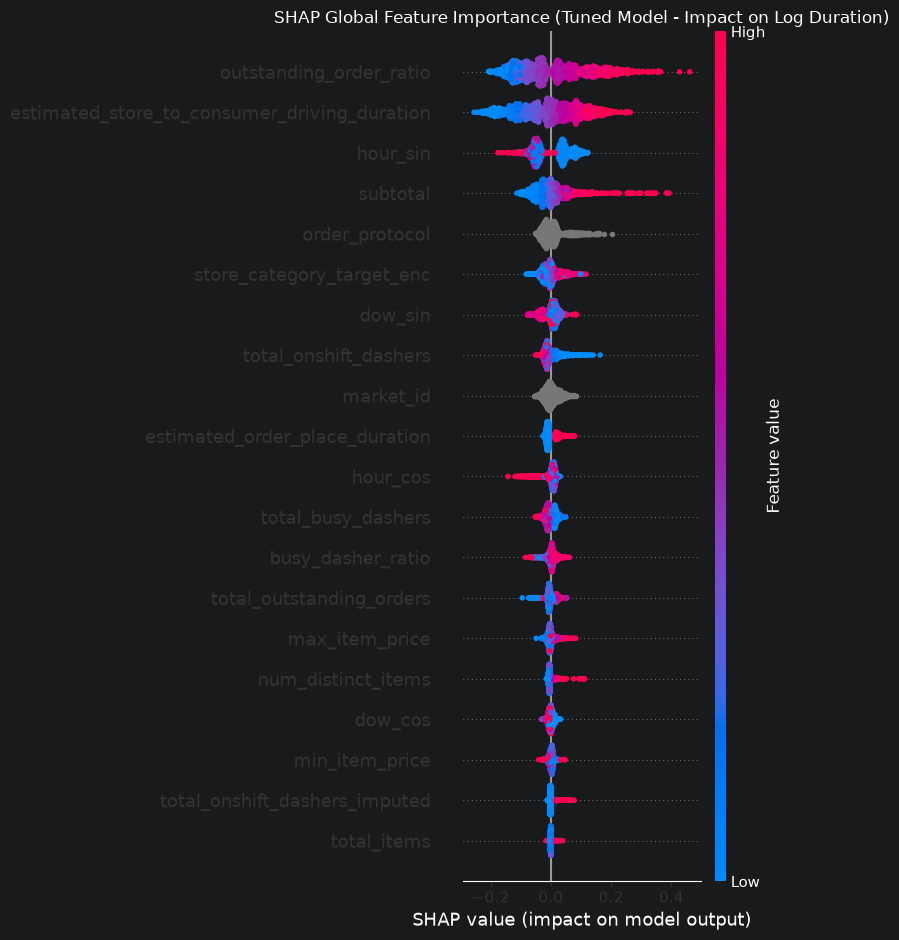

In [47]:
# Global Explainability: SHAP Summary (Beeswarm) Plot
print("Generating Global Feature Importance for Tuned Model...")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("SHAP Global Feature Importance (Tuned Model - Impact on Log Duration)")
plt.tight_layout()
plt.show()


Generating Local Explainability for Order Index 1453...


<Figure size 1000x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Why did the Tuned Model predict a long ETA for Order 1453?')

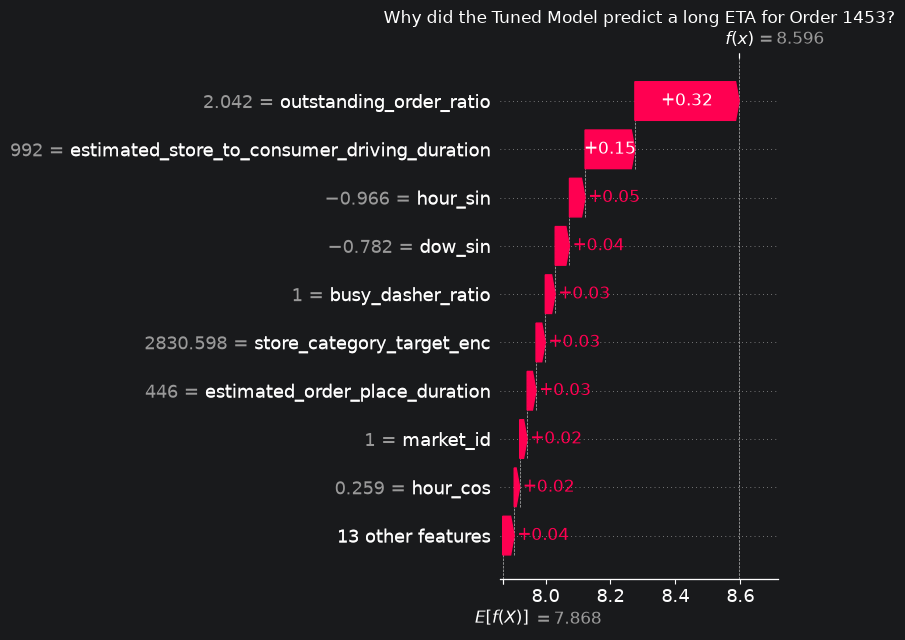

In [48]:
# Local Explainability: Waterfall Plot for a Problematic Order
# Let's find an order in our sample where the model predicted a very long delivery time
high_eta_idx = np.argmax(lgbm_final_p50.predict(X_test_sample))

print(f"\nGenerating Local Explainability for Order Index {high_eta_idx}...")
plt.figure(figsize=(10, 6))
# SHAP waterfall plots require the Explanation object for a single instance
shap.plots.waterfall(shap_values[high_eta_idx], max_display=10, show=False)
plt.title(f"Why did the Tuned Model predict a long ETA for Order {high_eta_idx}?")
plt.tight_layout()
plt.show()

# Export the best model for production use

In [53]:
# Define the exact feature list the model expects (the feature contract)
expected_features = X_train.columns.tolist()

In [56]:
# Load target encoding artifacts from feature engineering (or recompute if missing)
encoding_path = "../data/processed/category_target_encoding.joblib"

if os.path.exists(encoding_path):
    target_enc_data = joblib.load(encoding_path)
    category_encoding_map = target_enc_data["category_encoding_map"]
    global_mean = target_enc_data["global_mean"]
else:
    # Fallback: recompute from cleaned data
    cleaned_df = pd.read_parquet("../data/processed/cleaned_data.parquet")
    cleaned_df["order_date"] = cleaned_df["created_at_local"].dt.date
    cleaned_df = cleaned_df.sort_values("created_at_local").reset_index(drop=True)
    cutoff_date = pd.Timestamp("2015-02-11").date()
    train_mask = cleaned_df["order_date"] < cutoff_date
    SMOOTHING = 20
    global_mean = float(cleaned_df.loc[train_mask, "total_delivery_duration"].mean())
    category_stats = (
        cleaned_df.loc[train_mask]
        .groupby("store_primary_category")["total_delivery_duration"]
        .agg(["mean", "count"])
    )
    category_stats["smoothed_mean"] = (
        (category_stats["mean"] * category_stats["count"] + global_mean * SMOOTHING)
        / (category_stats["count"] + SMOOTHING)
    )
    category_encoding_map = category_stats["smoothed_mean"].to_dict()
    os.makedirs(os.path.dirname(encoding_path), exist_ok=True)
    joblib.dump({"category_encoding_map": category_encoding_map, "global_mean": global_mean}, encoding_path)

print(f"Loaded store category encoding map: {len(category_encoding_map)} categories")
print(f"Global category mean: {global_mean:.2f}")

# Create the deployment bundle
delivery_bundle = {
    "model_p10": lgbm_final_p10,
    "model_p50": lgbm_final_p50,  # The primary MAE model
    "model_p90": lgbm_final_p90,
    "store_category_map": category_encoding_map,
    "global_category_mean": global_mean,  # Fallback for unseen restaurants
    "feature_names": expected_features
}

Loaded store category encoding map: 75 categories
Global category mean: 2804.79


In [57]:
# Serialize and save to disk
model_path = "../models/delivery_model_bundle.joblib"
joblib.dump(delivery_bundle, model_path)

print(f"Successfully saved DeliveryOps bundle to {model_path}")
print(f"Expected feature count: {len(expected_features)}")
print("Bundle contents:", list(delivery_bundle.keys()))

['../models/delivery_model_bundle.joblib']

Successfully saved DeliveryOps bundle to ../models/delivery_model_bundle.joblib
Expected feature count: 22
Bundle contents: ['model_p10', 'model_p50', 'model_p90', 'store_category_map', 'global_category_mean', 'feature_names']
